# Objectif 1 — Prédiction du Churn Client (30 jours)

**Cible** : `Churn_30j` (0 = reste, 1 = churne dans les 30 jours)  
**Type** : Classification binaire  
**Source** : Data Warehouse `DW_TT` — Tunisie Telecom  

---
| Étape | Contenu |
|---|---|
| 1 | Chargement des données (SQL) |
| 2 | Analyse exploratoire (EDA) |
| 3 | Pré-traitement & encodage |
| 4 | Gestion du déséquilibre de classes |
| 5 | Entraînement des modèles |
| 6 | Évaluation & comparaison |
| 7 | Importance des features |
| 8 | Résumé & meilleur modèle |

## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
print('Libraries loaded OK')

Libraries loaded OK


## 1. Chargement des Données depuis PostgreSQL

In [2]:
DB_PARAMS = {
    'host': 'localhost',
    'database': 'DW_TT',
    'user': 'postgres',
    'password': 'Sarra123',
    'port': '5432'
}

engine = create_engine(
    f"postgresql://{DB_PARAMS['user']}:{DB_PARAMS['password']}"
    f"@{DB_PARAMS['host']}:{DB_PARAMS['port']}/{DB_PARAMS['database']}"
)
print('Connexion PostgreSQL OK')

Connexion PostgreSQL OK


In [3]:
# Stratégie :
#   - Cible  : Fact_churn pour DateFK=36 (Décembre 2024, période la plus récente)
#   - Features comportementales : agrégation sur 12 mois 2024 depuis Fact_performance_client
#   - Features client : dim_client, dim_geographique, dim_offre

QUERY = """
SELECT
    fc."ClientFK"                                         AS client_id,
    fc."Churn_30j"                                        AS churn,

    -- Dimension client
    dc."Sexe"                                             AS sexe,
    dc."Segment"                                          AS segment,
    dc."TypeAbonnement"                                   AS type_abonnement,
    dc."AncienneteMois"                                   AS anciennete_mois,
    dc."EngagementRestantMois"                            AS engagement_restant,

    -- Dimension géographique
    dg."Region"                                           AS region,
    dg."Gouvernorat"                                      AS gouvernorat,

    -- Dimension offre
    do_."OffreActuelle"                                   AS offre_actuelle,
    do_."PrixOffre"                                       AS prix_offre,

    -- Performance comportementale (agrégée sur tous les mois disponibles)
    AVG(fp."Minutes")              AS avg_minutes,
    AVG(fp."SMS")                  AS avg_sms,
    AVG(fp."DataGB")               AS avg_data_gb,
    AVG(fp."RoamingGB")            AS avg_roaming_gb,
    AVG(fp."UsageNocturneRatio")   AS avg_nocturne_ratio,
    AVG(fp."MontantFacture")       AS avg_montant_facture,
    AVG(fp."ARPU")                 AS avg_arpu,
    AVG(fp."HorsForfait")          AS avg_hors_forfait,
    SUM(fp."Impayes")              AS total_impayes,
    MAX(fp."RetardPaiementJours")  AS max_retard_paiement,
    AVG(fp."RetardPaiementJours")  AS avg_retard_paiement,
    SUM(fp."Tickets")              AS total_tickets,
    AVG(fp."DelaiResolutionJ")     AS avg_delai_resolution,
    AVG(fp."NPS")                  AS avg_nps,
    AVG(fp."QoSScore")             AS avg_qos,
    AVG(fp."DropRatePct")          AS avg_drop_rate,
    AVG(fp."ThroughputMbps")       AS avg_throughput,
    AVG(fp."OutageMinutes")        AS avg_outage_min,
    COUNT(fp."DateFK")             AS nb_mois_observes

FROM public."Fact_churn" fc

INNER JOIN public."dim_client" dc
    ON fc."ClientFK" = dc."Client_PK"

LEFT JOIN public."dim_geographique" dg
    ON dc."ClientID" = dg."ClientID"

LEFT JOIN public."dim_offre" do_
    ON dc."ClientID" = do_."ClientID"

LEFT JOIN public."Fact_performance_client" fp
    ON fc."ClientFK" = fp."ClientFK"

WHERE fc."DateFK" = 36   -- Décembre 2024 uniquement

GROUP BY
    fc."ClientFK", fc."Churn_30j",
    dc."Sexe", dc."Segment", dc."TypeAbonnement",
    dc."AncienneteMois", dc."EngagementRestantMois",
    dg."Region", dg."Gouvernorat",
    do_."OffreActuelle", do_."PrixOffre"

ORDER BY fc."ClientFK";
"""

df = pd.read_sql(QUERY, engine)
print(f'Dataset chargé : {df.shape[0]} clients × {df.shape[1]} colonnes')
df.head()

Dataset chargé : 422 clients × 30 colonnes


,client_id,churn,sexe,segment,type_abonnement,anciennete_mois,engagement_restant,region,gouvernorat,offre_actuelle,...,max_retard_paiement,avg_retard_paiement,total_tickets,avg_delai_resolution,avg_nps,avg_qos,avg_drop_rate,avg_throughput,avg_outage_min,nb_mois_observes
0,45,1,H,Postpayé,Postpayé,19,7,Centre-Est,Monastir,TT Max,...,0,0.000000,2,0.666667,28.500000,87.883333,2.796667,24.541667,2.416667,12
1,99,1,H,Prépayé,Prépayé,119,0,Nord-Est,Zaghouan,TT Pro,...,19,1.583333,2,0.416667,46.250000,81.616667,4.066667,29.091667,6.250000,12
2,110,1,F,Prépayé,Prépayé,82,0,Centre-Est,Mahdia,TT Start,...,27,4.416667,3,0.833333,42.083333,85.875001,4.146667,23.358333,4.250000,12
3,122,1,F,Prépayé,Prépayé,8,0,Nord-Est,Zaghouan,TT Start,...,0,0.000000,5,1.333333,38.333333,84.408333,3.174167,22.633333,0.000000,12
4,141,1,F,Prépayé,Prépayé,68,0,Centre-Est,Mahdia,TT Pro,...,0,0.000000,3,1.250000,45.583333,88.133333,3.700000,24.791666,4.750000,12


In [4]:
print('=== Infos générales ===')
print(df.dtypes)
print()
print('=== Valeurs manquantes ===')
null_pct = df.isnull().mean().mul(100).round(2)
print(null_pct[null_pct > 0] if null_pct.any() else 'Aucune valeur manquante')

=== Infos générales ===
client_id                 int64
churn                     int64
sexe                     object
segment                  object
type_abonnement          object
anciennete_mois           int64
engagement_restant        int64
region                   object
gouvernorat              object
offre_actuelle           object
prix_offre                int64
avg_minutes             float64
avg_sms                 float64
avg_data_gb             float64
avg_roaming_gb          float64
avg_nocturne_ratio      float64
avg_montant_facture     float64
avg_arpu                float64
avg_hors_forfait        float64
total_impayes             int64
max_retard_paiement       int64
avg_retard_paiement     float64
total_tickets             int64
avg_delai_resolution    float64
avg_nps                 float64
avg_qos                 float64
avg_drop_rate           float64
avg_throughput          float64
avg_outage_min          float64
nb_mois_observes          int64
dtype: object

=

## 2. Analyse Exploratoire (EDA)

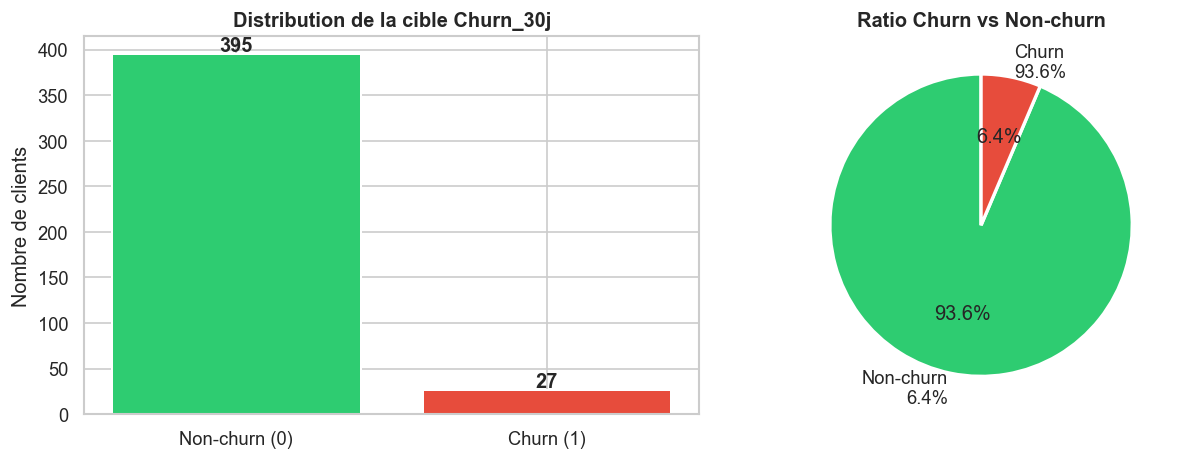

Classe 0 (non-churn) :   27 (6.4%)
Classe 1 (churn)     :  395 (93.6%)
Ratio déséquilibre   : 1 : 14


In [5]:
# --- Distribution de la cible ---
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Non-churn (0)', 'Churn (1)'], churn_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribution de la cible Churn_30j', fontweight='bold')
axes[0].set_ylabel('Nombre de clients')

axes[1].pie(churn_counts.values, labels=[f'Non-churn\n{churn_pct[0]}%', f'Churn\n{churn_pct[1]}%'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Ratio Churn vs Non-churn', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_churn_distribution.png', bbox_inches='tight')
plt.show()

print(f'Classe 0 (non-churn) : {churn_counts[0]:>4} ({churn_pct[0]}%)')
print(f'Classe 1 (churn)     : {churn_counts[1]:>4} ({churn_pct[1]}%)')
print(f'Ratio déséquilibre   : 1 : {churn_counts[1]//churn_counts[0]}')

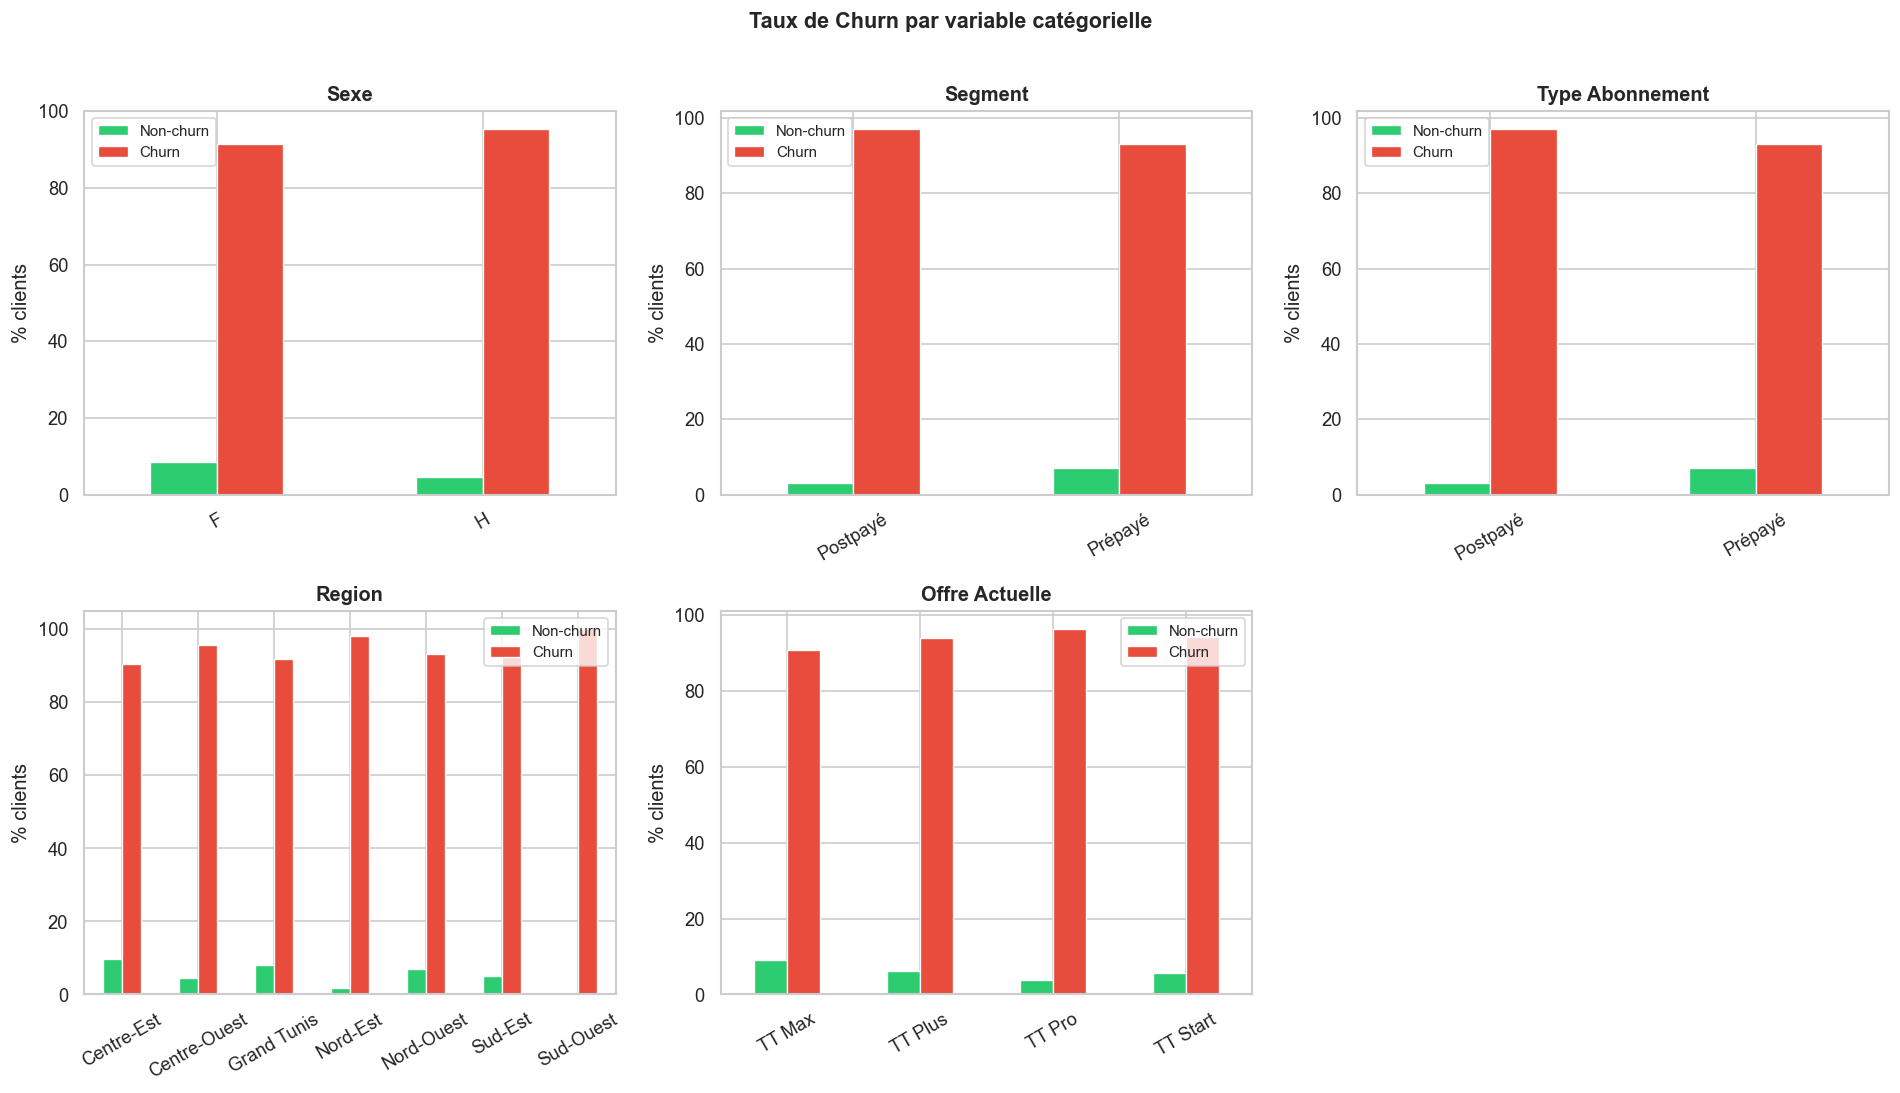

In [6]:
# --- Features catégorielles vs Churn ---
cat_cols = ['sexe', 'segment', 'type_abonnement', 'region', 'offre_actuelle']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['churn'], normalize='index').mul(100).round(1)
    ct.columns = ['Non-churn', 'Churn']
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=0.8)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_ylabel('% clients')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Taux de Churn par variable catégorielle', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_cat_vs_churn.png', bbox_inches='tight')
plt.show()

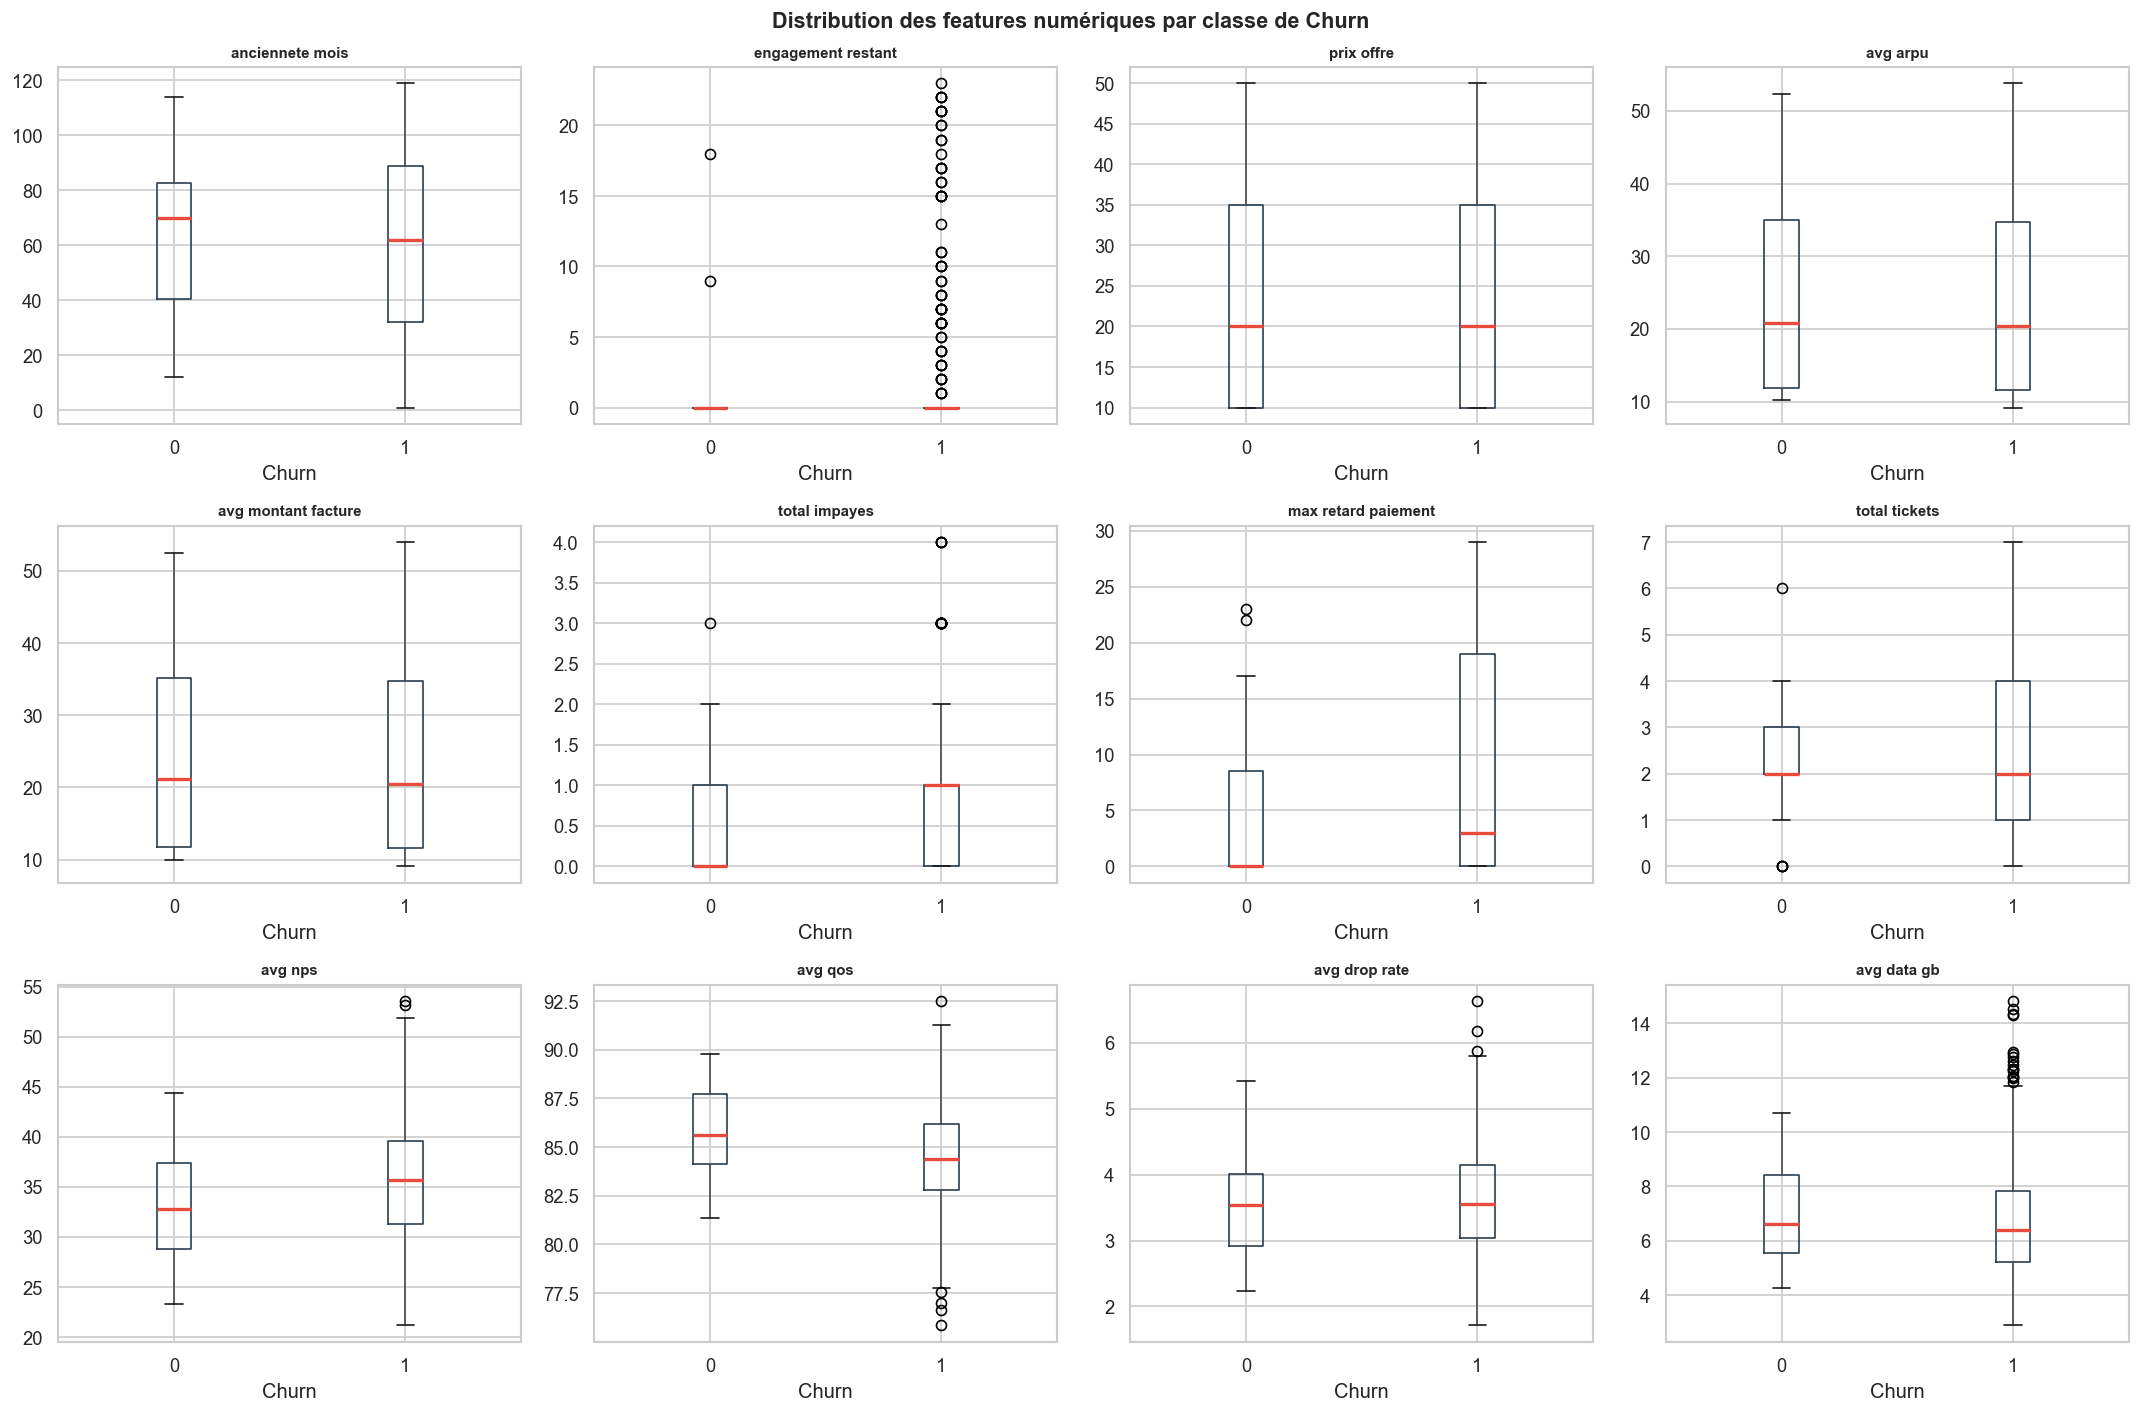

In [7]:
# --- Features numériques clés : boxplots Churn 0 vs 1 ---
num_key = [
    'anciennete_mois', 'engagement_restant', 'prix_offre',
    'avg_arpu', 'avg_montant_facture', 'total_impayes',
    'max_retard_paiement', 'total_tickets', 'avg_nps',
    'avg_qos', 'avg_drop_rate', 'avg_data_gb'
]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_key):
    df.boxplot(column=col, by='churn', ax=axes[i],
               boxprops=dict(color='#2c3e50'),
               medianprops=dict(color='#e74c3c', linewidth=2))
    axes[i].set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel('')

plt.suptitle('Distribution des features numériques par classe de Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_num_boxplots.png', bbox_inches='tight')
plt.show()

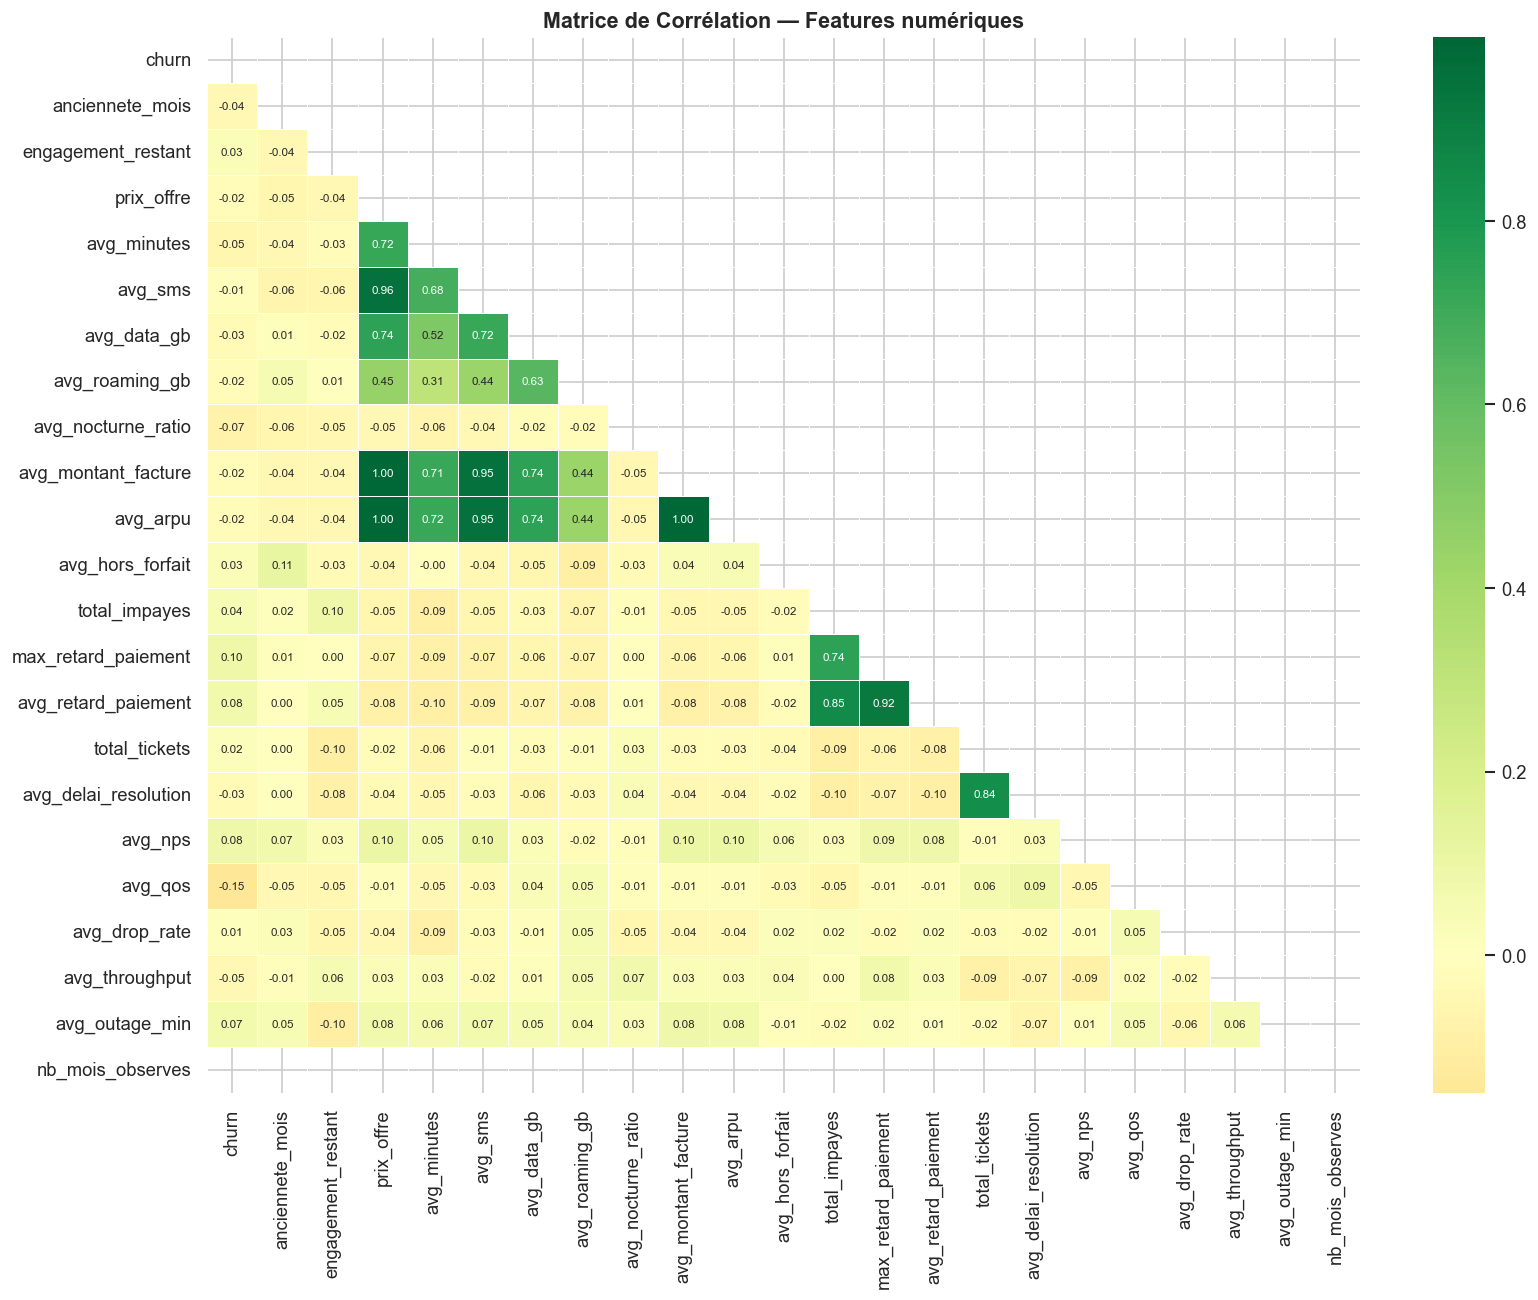

In [8]:
# --- Matrice de corrélation ---
num_cols = df.select_dtypes(include=np.number).columns.drop('client_id').tolist()
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Matrice de Corrélation — Features numériques', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

In [9]:
# --- Statistiques descriptives (churn=0 vs churn=1) ---
print('=== Moyennes par classe de churn ===')
df.groupby('churn')[num_key].mean().T.round(2)

=== Moyennes par classe de churn ===


churn,0,1
anciennete_mois,65.78,60.15
engagement_restant,1.00,1.59
prix_offre,21.85,20.77
avg_arpu,23.11,22.21
avg_montant_facture,23.10,22.21
total_impayes,0.63,0.77
max_retard_paiement,5.07,9.15
total_tickets,2.37,2.51
avg_nps,33.59,35.56
avg_qos,85.88,84.33


## 3. Pré-traitement

In [10]:
df_ml = df.copy()

# Colonnes à supprimer
drop_cols = ['client_id', 'gouvernorat']  # trop granulaire
df_ml.drop(columns=drop_cols, inplace=True)

# Encodage des variables catégorielles
cat_features = ['sexe', 'segment', 'type_abonnement', 'region', 'offre_actuelle']
le_dict = {}
for col in cat_features:
    df_ml[col] = df_ml[col].astype(str).str.strip()
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    le_dict[col] = le
    print(f'{col:25}: {list(le.classes_)}')

print(f'\nShape après encodage : {df_ml.shape}')

sexe                     : ['F', 'H']
segment                  : ['Postpayé', 'Prépayé']
type_abonnement          : ['Postpayé', 'Prépayé']
region                   : ['Centre-Est', 'Centre-Ouest', 'Grand Tunis', 'Nord-Est', 'Nord-Ouest', 'Sud-Est', 'Sud-Ouest']
offre_actuelle           : ['TT Max', 'TT Plus', 'TT Pro', 'TT Start']

Shape après encodage : (422, 28)


In [11]:
# Gestion des valeurs manquantes (imputation par médiane)
null_counts = df_ml.isnull().sum()
if null_counts.any():
    print('Colonnes avec nulls (avant imputation):')
    print(null_counts[null_counts > 0])
    df_ml.fillna(df_ml.median(numeric_only=True), inplace=True)
    print('Imputation par médiane effectuée.')
else:
    print('Aucune valeur manquante.')

# Séparation features / cible
X = df_ml.drop(columns=['churn'])
y = df_ml['churn']

print(f'\nFeatures : {X.shape[1]} colonnes')
print(f'Cible    : {y.shape[0]} observations')
print(f'Colonnes : {list(X.columns)}')

Aucune valeur manquante.

Features : 27 colonnes
Cible    : 422 observations
Colonnes : ['sexe', 'segment', 'type_abonnement', 'anciennete_mois', 'engagement_restant', 'region', 'offre_actuelle', 'prix_offre', 'avg_minutes', 'avg_sms', 'avg_data_gb', 'avg_roaming_gb', 'avg_nocturne_ratio', 'avg_montant_facture', 'avg_arpu', 'avg_hors_forfait', 'total_impayes', 'max_retard_paiement', 'avg_retard_paiement', 'total_tickets', 'avg_delai_resolution', 'avg_nps', 'avg_qos', 'avg_drop_rate', 'avg_throughput', 'avg_outage_min', 'nb_mois_observes']


In [12]:
# Train / Test split (stratifié pour préserver le ratio de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Normalisation des features numériques
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')
print(f'Churn dans train : {y_train.value_counts().to_dict()}')
print(f'Churn dans test  : {y_test.value_counts().to_dict()}')

Train : 316 | Test : 106
Churn dans train : {1: 296, 0: 20}
Churn dans test  : {1: 99, 0: 7}


## 4. Gestion du Déséquilibre de Classes

> Le dataset présente un fort déséquilibre (~93% churn vs ~7% non-churn).  
> Stratégie : **SMOTE** sur le jeu d'entraînement uniquement.

In [13]:
print('=== Avant SMOTE ===')
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\n=== Après SMOTE ===')
print(pd.Series(y_train_sm).value_counts())

# Aussi scaler la version SMOTE
X_train_sm_sc = scaler.fit_transform(X_train_sm)
print(f'\nTrain augmenté : {X_train_sm.shape[0]} observations')

=== Avant SMOTE ===
churn
1    296
0     20
Name: count, dtype: int64



=== Après SMOTE ===
churn
1    296
0    296
Name: count, dtype: int64

Train augmenté : 592 observations


## 5. Entraînement des Modèles

Modèles testés :
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, use_scaled=False):
    """Entraîne et évalue un modèle. Retourne un dict de métriques."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'Modèle'    : name,
        'Accuracy'  : accuracy_score(y_te, y_pred),
        'Precision' : precision_score(y_te, y_pred, zero_division=0),
        'Recall'    : recall_score(y_te, y_pred, zero_division=0),
        'F1'        : f1_score(y_te, y_pred, zero_division=0),
        'AUC-ROC'   : roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan,
    }
    return metrics, model, y_pred, y_proba


# Définition des modèles
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE),
    'XGBoost'             : XGBClassifier(n_estimators=200, learning_rate=0.08, max_depth=5,
                                           scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1]),
                                           eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    'LightGBM'            : LGBMClassifier(n_estimators=200, learning_rate=0.08, max_depth=5,
                                            class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
}

print(f'{len(models)} modèles définis.')

6 modèles définis.


In [15]:
# --- Entraînement SANS SMOTE (class_weight intégré) ---
print('=== Entraînement sans SMOTE (class_weight) ===')
results_no_smote = []
trained_models = {}

for name, model in models.items():
    if name in ('Logistic Regression',):
        metrics, m, yp, yproba = evaluate_model(name, model, X_train_sc, y_train, X_test_sc, y_test)
    else:
        metrics, m, yp, yproba = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results_no_smote.append(metrics)
    trained_models[name] = (m, yp, yproba)
    print(f"  {name:<22} | F1={metrics['F1']:.3f} | AUC={metrics['AUC-ROC']:.3f} | Recall={metrics['Recall']:.3f}")

df_results_no_smote = pd.DataFrame(results_no_smote).set_index('Modèle').sort_values('F1', ascending=False)
print()
df_results_no_smote.round(4)

=== Entraînement sans SMOTE (class_weight) ===
  Logistic Regression    | F1=0.781 | AUC=0.608 | Recall=0.667
  Decision Tree          | F1=0.762 | AUC=0.465 | Recall=0.646


  Random Forest          | F1=0.966 | AUC=0.427 | Recall=1.000


  Gradient Boosting      | F1=0.955 | AUC=0.459 | Recall=0.970


  XGBoost                | F1=0.918 | AUC=0.395 | Recall=0.909
  LightGBM               | F1=0.956 | AUC=0.499 | Recall=0.980



,Accuracy,Precision,Recall,F1,AUC-ROC
Modèle,,,,,
Random Forest,0.9340,0.9340,1.0000,0.9659,0.4271
LightGBM,0.9151,0.9327,0.9798,0.9557,0.4993
Gradient Boosting,0.9151,0.9412,0.9697,0.9552,0.4589
XGBoost,0.8491,0.9278,0.9091,0.9184,0.3954
Logistic Regression,0.6509,0.9429,0.6667,0.7811,0.6075
Decision Tree,0.6226,0.9275,0.6465,0.7619,0.4646


In [16]:
# --- Entraînement AVEC SMOTE ---
print('=== Entraînement avec SMOTE ===')

models_smote = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE),
    'XGBoost'             : XGBClassifier(n_estimators=200, learning_rate=0.08, max_depth=5,
                                           eval_metric='logloss', random_state=RANDOM_STATE, verbosity=0),
    'LightGBM'            : LGBMClassifier(n_estimators=200, learning_rate=0.08, max_depth=5,
                                            random_state=RANDOM_STATE, verbose=-1),
}

results_smote = []
trained_models_smote = {}

for name, model in models_smote.items():
    if name == 'Logistic Regression':
        metrics, m, yp, yproba = evaluate_model(name, model, X_train_sm_sc, y_train_sm, X_test_sc, y_test)
    else:
        metrics, m, yp, yproba = evaluate_model(name, model, X_train_sm, y_train_sm, X_test, y_test)
    results_smote.append(metrics)
    trained_models_smote[name] = (m, yp, yproba)
    print(f"  {name:<22} | F1={metrics['F1']:.3f} | AUC={metrics['AUC-ROC']:.3f} | Recall={metrics['Recall']:.3f}")

df_results_smote = pd.DataFrame(results_smote).set_index('Modèle').sort_values('F1', ascending=False)
print()
df_results_smote.round(4)

=== Entraînement avec SMOTE ===
  Logistic Regression    | F1=0.675 | AUC=0.654 | Recall=0.515
  Decision Tree          | F1=0.807 | AUC=0.421 | Recall=0.717


  Random Forest          | F1=0.956 | AUC=0.400 | Recall=0.980


  Gradient Boosting      | F1=0.940 | AUC=0.407 | Recall=0.949
  XGBoost                | F1=0.945 | AUC=0.524 | Recall=0.960


  LightGBM               | F1=0.945 | AUC=0.561 | Recall=0.960



,Accuracy,Precision,Recall,F1,AUC-ROC
Modèle,,,,,
Random Forest,0.9151,0.9327,0.9798,0.9557,0.3997
XGBoost,0.8962,0.9314,0.9596,0.9453,0.5238
LightGBM,0.8962,0.9314,0.9596,0.9453,0.5613
Gradient Boosting,0.8868,0.9307,0.9495,0.9400,0.4069
Decision Tree,0.6792,0.9221,0.7172,0.8068,0.4206
Logistic Regression,0.5377,0.9808,0.5152,0.6755,0.6537


## 6. Évaluation & Comparaison

In [17]:
# --- Tableau comparatif global ---
df_no = df_results_no_smote.copy().add_suffix('_NoSMOTE')
df_sm = df_results_smote.copy().add_suffix('_SMOTE')
df_compare = pd.concat([df_no, df_sm], axis=1)

print('=== Comparaison No-SMOTE vs SMOTE (F1) ===')
comparison = pd.DataFrame({
    'F1 (No-SMOTE)' : df_results_no_smote['F1'],
    'F1 (SMOTE)'    : df_results_smote['F1'],
    'AUC (No-SMOTE)': df_results_no_smote['AUC-ROC'],
    'AUC (SMOTE)'   : df_results_smote['AUC-ROC'],
}).round(4)

print(comparison.sort_values('F1 (SMOTE)', ascending=False))

=== Comparaison No-SMOTE vs SMOTE (F1) ===
                     F1 (No-SMOTE)  F1 (SMOTE)  AUC (No-SMOTE)  AUC (SMOTE)
Modèle                                                                     
Random Forest               0.9659      0.9557          0.4271       0.3997
LightGBM                    0.9557      0.9453          0.4993       0.5613
XGBoost                     0.9184      0.9453          0.3954       0.5238
Gradient Boosting           0.9552      0.9400          0.4589       0.4069
Decision Tree               0.7619      0.8068          0.4646       0.4206
Logistic Regression         0.7811      0.6755          0.6075       0.6537


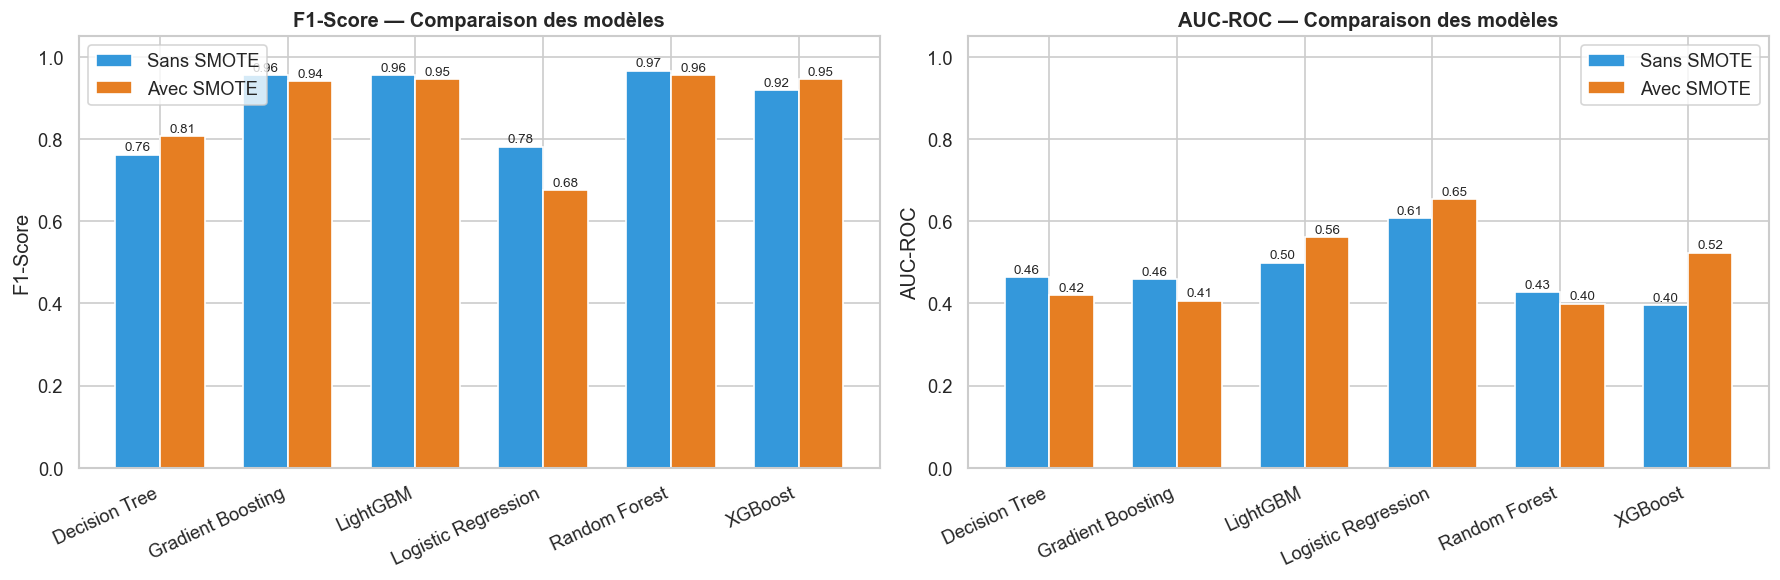

In [18]:
# --- Graphique comparatif F1 & AUC ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, title in zip(axes, ['F1', 'AUC-ROC'], ['F1-Score', 'AUC-ROC']):
    x = np.arange(len(df_results_no_smote))
    width = 0.35
    bars1 = ax.bar(x - width/2, df_results_no_smote.sort_index()[metric], width,
                   label='Sans SMOTE', color='#3498db', edgecolor='white')
    bars2 = ax.bar(x + width/2, df_results_smote.sort_index()[metric], width,
                   label='Avec SMOTE', color='#e67e22', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(df_results_no_smote.sort_index().index, rotation=25, ha='right')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{title} — Comparaison des modèles', fontweight='bold')
    ax.legend()
    ax.set_ylabel(title)
    for bar in [*bars1, *bars2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison_f1_auc.png', bbox_inches='tight')
plt.show()

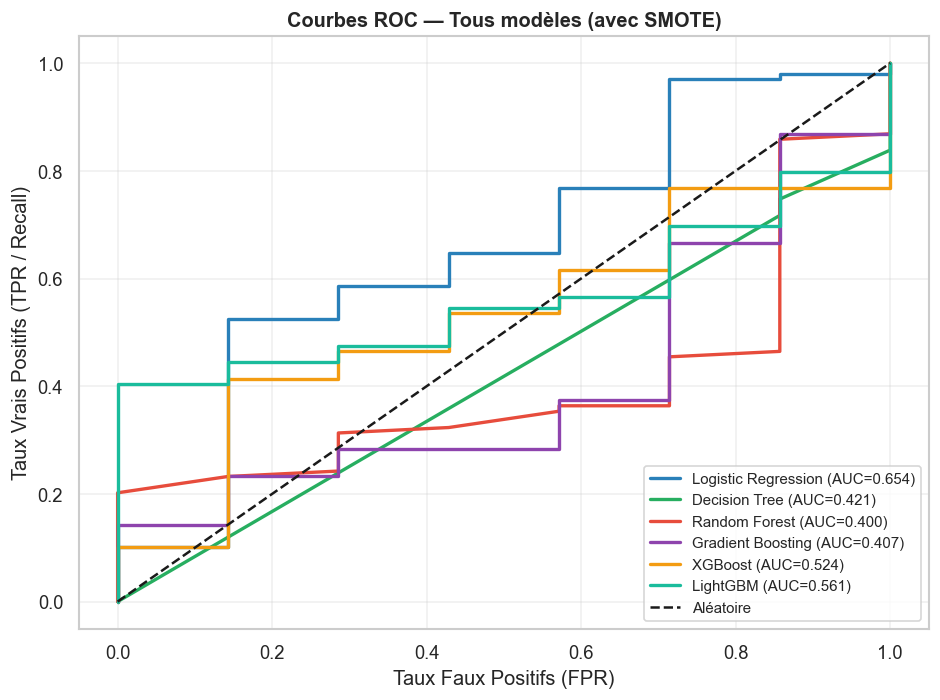

In [19]:
# --- Courbes ROC (meilleure config : SMOTE) ---
fig, ax = plt.subplots(figsize=(8, 6))

colors_roc = ['#2980b9', '#27ae60', '#e74c3c', '#8e44ad', '#f39c12', '#1abc9c']
for (name, (model, yp, yproba)), color in zip(trained_models_smote.items(), colors_roc):
    if yproba is not None:
        fpr, tpr, _ = roc_curve(y_test, yproba)
        auc = roc_auc_score(y_test, yproba)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Aléatoire')
ax.set_xlabel('Taux Faux Positifs (FPR)')
ax.set_ylabel('Taux Vrais Positifs (TPR / Recall)')
ax.set_title('Courbes ROC — Tous modèles (avec SMOTE)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

In [20]:
# --- Identifier le meilleur modèle ---
best_name = df_results_smote['F1'].idxmax()
best_model, best_pred, best_proba = trained_models_smote[best_name]

print(f'Meilleur modèle (F1) : {best_name}')
print(f'F1    = {f1_score(y_test, best_pred):.4f}')
print(f'AUC   = {roc_auc_score(y_test, best_proba):.4f}')
print()
print('=== Rapport de Classification ===')
print(classification_report(y_test, best_pred, target_names=['Non-churn', 'Churn']))

Meilleur modèle (F1) : Random Forest
F1    = 0.9557
AUC   = 0.3997

=== Rapport de Classification ===
              precision    recall  f1-score   support

   Non-churn       0.00      0.00      0.00         7
       Churn       0.93      0.98      0.96        99

    accuracy                           0.92       106
   macro avg       0.47      0.49      0.48       106
weighted avg       0.87      0.92      0.89       106



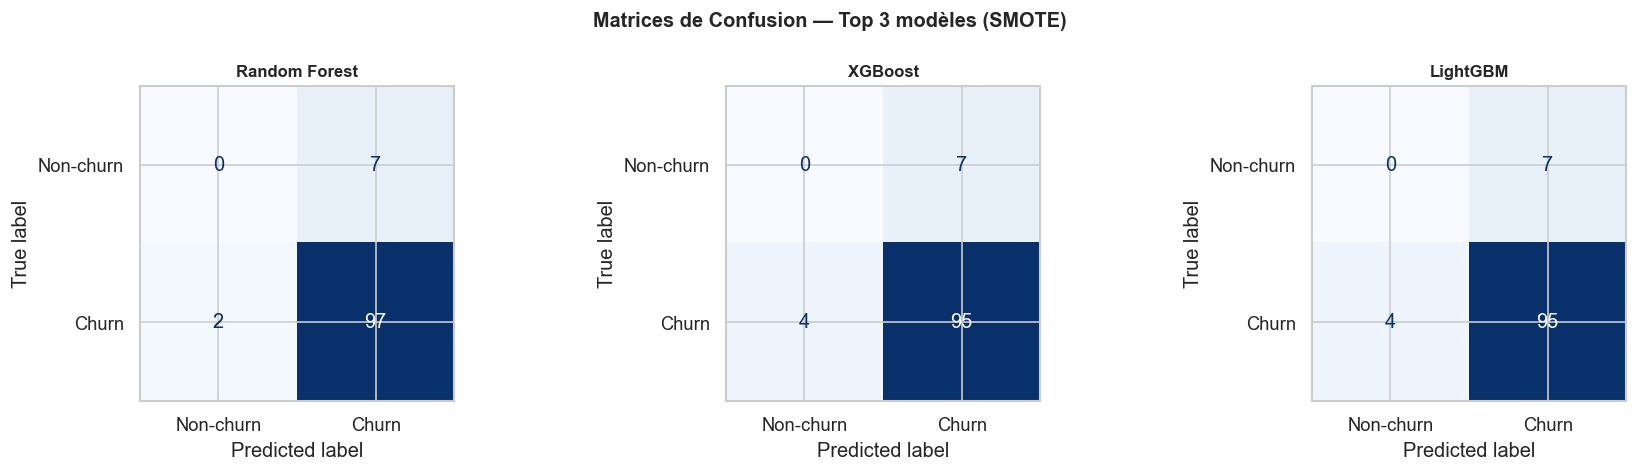

In [21]:
# --- Matrices de confusion (top 3 modèles) ---
top3 = df_results_smote['F1'].nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, top3):
    m, yp, _ = trained_models_smote[name]
    cm = confusion_matrix(y_test, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=10)

plt.suptitle('Matrices de Confusion — Top 3 modèles (SMOTE)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_top3.png', bbox_inches='tight')
plt.show()

## 7. Importance des Features

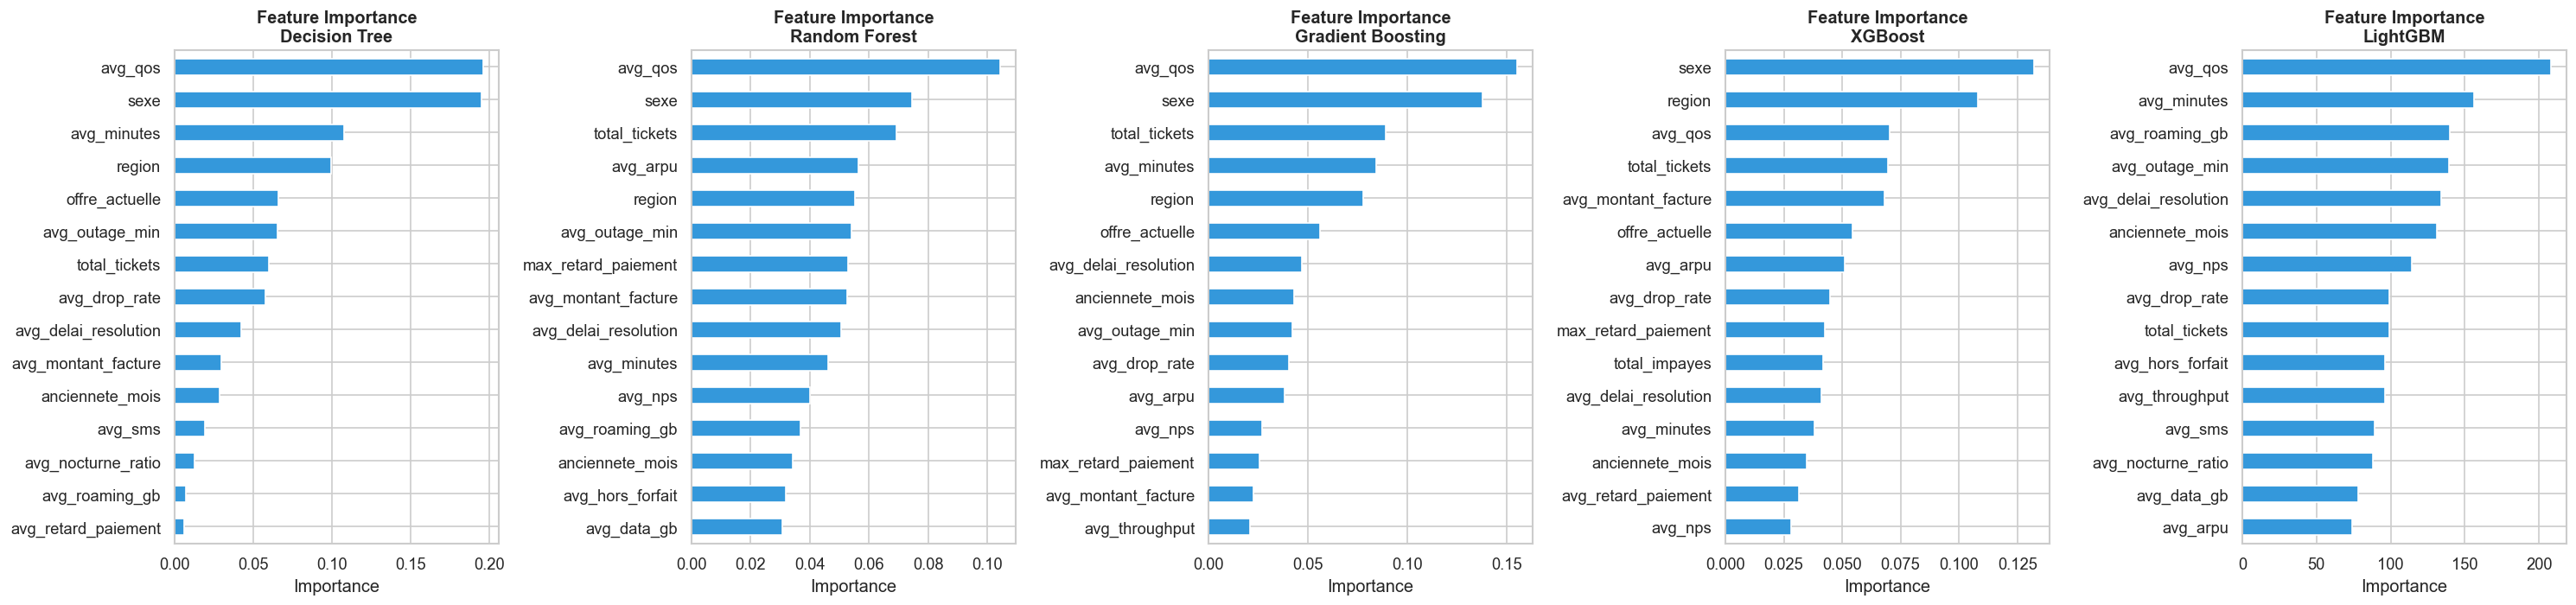

In [22]:
# Feature importance des modèles tree-based
tree_models = {k: v[0] for k, v in trained_models_smote.items()
               if hasattr(v[0], 'feature_importances_')}

fig, axes = plt.subplots(1, len(tree_models), figsize=(5 * len(tree_models), 6))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top_feat = importances.nlargest(15).sort_values()
    top_feat.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
    ax.set_title(f'Feature Importance\n{name}', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

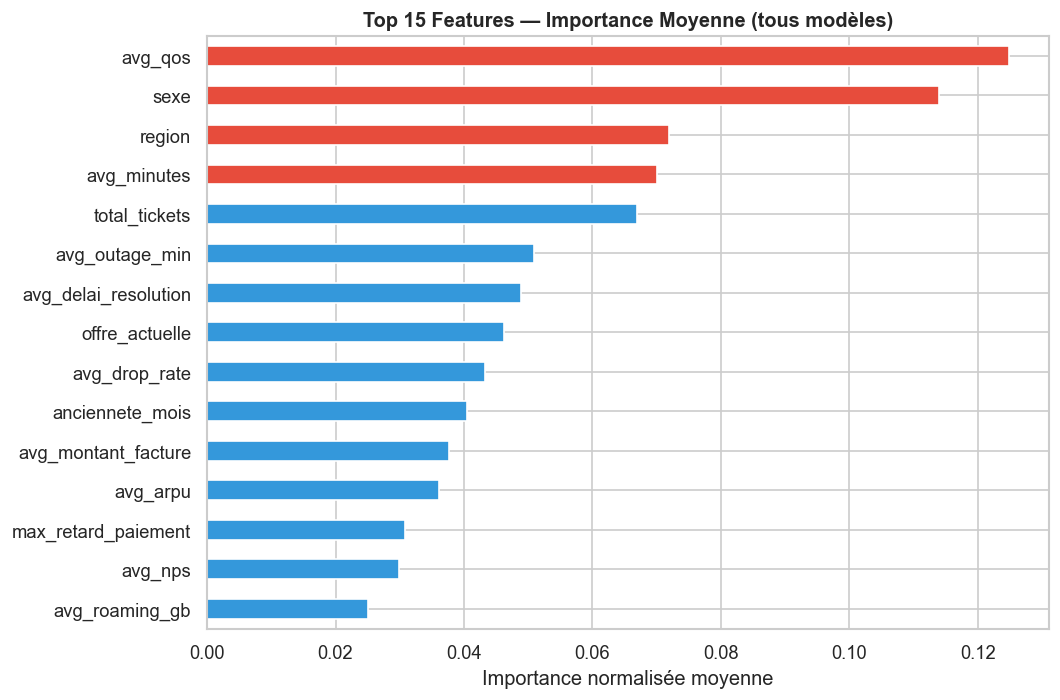

Top 10 features prédictives de churn :
avg_qos                 0.1248
sexe                    0.1139
region                  0.0720
avg_minutes             0.0701
total_tickets           0.0670
avg_outage_min          0.0508
avg_delai_resolution    0.0488
offre_actuelle          0.0463
avg_drop_rate           0.0434
anciennete_mois         0.0405
Name: mean, dtype: float64


In [23]:
# Consensus des top features (moyenne des importances normalisées)
imp_df = pd.DataFrame()
for name, model in tree_models.items():
    imp = pd.Series(model.feature_importances_, index=X.columns)
    imp_df[name] = imp / imp.sum()  # normalisation

imp_df['mean'] = imp_df.mean(axis=1)
top15_consensus = imp_df['mean'].nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = ['#e74c3c' if v > top15_consensus.quantile(0.75) else '#3498db'
              for v in top15_consensus.values]
top15_consensus.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.set_title('Top 15 Features — Importance Moyenne (tous modèles)', fontweight='bold')
ax.set_xlabel('Importance normalisée moyenne')
plt.tight_layout()
plt.savefig('feature_importance_consensus.png', bbox_inches='tight')
plt.show()

print('Top 10 features prédictives de churn :')
print(imp_df['mean'].nlargest(10).round(4))

## 8. Résumé & Meilleur Modèle

In [24]:
# Tableau récap complet
print('=' * 70)
print('RÉSUMÉ — Prédiction Churn 30 jours')
print('=' * 70)
print(f'Dataset        : {df.shape[0]} clients, {X.shape[1]} features')
print(f'Déséquilibre   : {y.value_counts()[1]} churn ({y.mean()*100:.1f}%) / {y.value_counts()[0]} non-churn')
print(f'Train/Test     : {len(y_train)}/{len(y_test)} (75/25, stratifié)')
print(f'SMOTE          : {X_train_sm.shape[0]} samples après rééchantillonnage')
print()
print('--- Résultats avec SMOTE ---')
print(df_results_smote[['Accuracy','Precision','Recall','F1','AUC-ROC']].round(4)
                       .sort_values('F1', ascending=False).to_string())
print()
print(f'>>> Meilleur modèle : {best_name}')
print(f'    F1      = {f1_score(y_test, best_pred):.4f}')
print(f'    AUC-ROC = {roc_auc_score(y_test, best_proba):.4f}')
print(f'    Recall  = {recall_score(y_test, best_pred):.4f}')
print('=' * 70)

RÉSUMÉ — Prédiction Churn 30 jours
Dataset        : 422 clients, 27 features
Déséquilibre   : 395 churn (93.6%) / 27 non-churn
Train/Test     : 316/106 (75/25, stratifié)
SMOTE          : 592 samples après rééchantillonnage

--- Résultats avec SMOTE ---
                     Accuracy  Precision  Recall      F1  AUC-ROC
Modèle                                                           
Random Forest          0.9151     0.9327  0.9798  0.9557   0.3997
XGBoost                0.8962     0.9314  0.9596  0.9453   0.5238
LightGBM               0.8962     0.9314  0.9596  0.9453   0.5613
Gradient Boosting      0.8868     0.9307  0.9495  0.9400   0.4069
Decision Tree          0.6792     0.9221  0.7172  0.8068   0.4206
Logistic Regression    0.5377     0.9808  0.5152  0.6755   0.6537

>>> Meilleur modèle : Random Forest
    F1      = 0.9557
    AUC-ROC = 0.3997
    Recall  = 0.9798


In [25]:
# Sauvegarder les résultats pour le MD
import json, datetime

run_results = {
    'run_date'   : datetime.datetime.now().isoformat(),
    'dataset'    : {'rows': int(df.shape[0]), 'features': int(X.shape[1])},
    'imbalance'  : {'churn_1': int(y.sum()), 'churn_0': int((y==0).sum())},
    'no_smote'   : df_results_no_smote.reset_index().to_dict(orient='records'),
    'with_smote' : df_results_smote.reset_index().to_dict(orient='records'),
    'best_model' : best_name,
    'best_f1'    : float(f1_score(y_test, best_pred)),
    'best_auc'   : float(roc_auc_score(y_test, best_proba)),
}

with open('01_churn_run_log.json', 'w') as f:
    json.dump(run_results, f, indent=2)

print('Résultats sauvegardés dans 01_churn_run_log.json')

Résultats sauvegardés dans 01_churn_run_log.json
